# Ejercicio 2

El dataset `alimentos.csv` fue elaborado por una clínica de nutrición que suministró a sus pacientes una lista de alimentos permitidos con sus respectivos contenidos calóricos. También se detalló el tipo de alimento del que se trataba (fruta, verdura, etc.) y el tipo de vitamina que aportaba cada uno (A, B o C).

Por otra parte, la nutricionista a cargo del estudio lleva una planilla de control de la evolución de 50 pacientes (`pacientes.csv`) en la que registra la edad, el sexo, la altura, el peso inicial y el peso final de cada uno de ellos luego de seguir un plan de dieta por una cierta cantidad de tiempo, información que también fue registrada en el campo “tiempo de tratamiento”.

1. Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y/o adecuación de los mismos que considere necesaria.

2. En relación al campo `aporte_calorico_kcal` informe las medidas descriptivas que le brinden información sobre los siguientes aspectos:

    - Las kcal que aportan, en promedio, los alimentos que forman parte del dataset.

    - Aquel valor de aporte calórico tal que el 50% de los alimentos del dataset presentan aportes calóricos menores o iguales a él.

    - La dispersión o variabilidad del 50% central de las observaciones.

    - El o los valores que se presentan con mayor frecuencia entre las observaciones.

3. Represente la distribución de las observaciones de la variable `aporte_calorico_kcal` a través de un boxplot.

    - Identifique en el gráfico la mediana, el primer y el tercer cuartil.

    - ¿Cómo caracterizaría a la distribución en relación a sus características de simetría?

    - En función a lo observado, ¿qué par de medidas de centralidad/posición (media aritmética - mediana) y de dispersión (rango intercuartil - rango - desviación estándar) le parece más adecuada para describir a este conjunto?

    - ¿Existe alguna observación que pueda ser considerada como atípica? En caso de respuesta afirmativa, ¿cuántas observaciones recibirían esta calificación?

4. ¿Qué tipo de alimento presenta la mayor mediana de aporte calórico?

5. Realice un boxplot para representar la distribución de los aportes calóricos de alimentos de los siguientes tipos: frutas, verduras y alimentos elaborados.

    - ¿Qué tipo de alimentos presenta valores calóricos más variables y cuál menos variables?

    - ¿Qué medida descriptiva utilizó para responder a estas últimas preguntas?

6. Utilizando los datos de los/las pacientes, genere una variable que corresponda a la variación de peso para cada paciente a lo largo del tratamiento (`peso_final_kg` - `peso_inicial_kg`).

    - Represente los valores observados de la variable “diferencia de peso” en función del sexo a través de un boxplot.

    - ¿Qué medida descriptiva utilizaría para comparar los resultados del tratamiento entre personas de ambos sexos? En función de su respuesta, ¿las personas de qué sexo obtuvieron los mejores resultados para el tratamiento?


In [47]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Cargamos el df de alimentos como df_alimentos

df_alimentos = pd.read_csv('../datasets/alimentos.csv', sep=';', encoding = 'latin_1')
df_alimentos.head()

,alimento,aporte_calorico_kcal,tipo_de_alimento,vitamina
0,banana,81,fruta,A
1,kiwi,36,fruta,B
2,higo,62,fruta,B
3,repollo,22,verdura,A
4,col,12,verdura,A


In [49]:
# Observemos su estructura

df_alimentos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   alimento              99 non-null     str  
 1   aporte_calorico_kcal  99 non-null     int64
 2   tipo_de_alimento      99 non-null     str  
 3   vitamina              99 non-null     str  
dtypes: int64(1), str(3)
memory usage: 3.2 KB


In [50]:
df_alimentos.columns

Index(['alimento', 'aporte_calorico_kcal', 'tipo_de_alimento', 'vitamina'], dtype='str')

In [51]:
df_alimentos.isna().sum()

alimento                0
aporte_calorico_kcal    0
tipo_de_alimento        0
vitamina                0
dtype: int64

In [52]:
# Cargamos el df de pacientes

df_pacientes = pd.read_csv('../datasets/pacientes.csv', sep=';', encoding = 'latin_1')
df_pacientes.head()

,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias
0,398911,78,72,"1,8",F,583
1,398912,68,68,"1,75",F,159
2,398913,92,70,"1,85",F,70
3,398914,66,64,"1,65",M,41
4,398915,51,50,"1,55",F,30


In [53]:
df_pacientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   codigo_paciente          50 non-null     int64
 1   peso_inicial_kg          50 non-null     int64
 2   peso_final_kg            50 non-null     int64
 3   altura_m                 50 non-null     str  
 4   sexo                     50 non-null     str  
 5   tiempo_tratamiento_dias  50 non-null     int64
dtypes: int64(4), str(2)
memory usage: 2.5 KB


In [54]:
df_pacientes.columns

Index(['codigo_paciente', 'peso_inicial_kg', 'peso_final_kg', 'altura_m',
       'sexo', 'tiempo_tratamiento_dias'],
      dtype='str')

In [55]:
df_pacientes.isna().sum()

codigo_paciente            0
peso_inicial_kg            0
peso_final_kg              0
altura_m                   0
sexo                       0
tiempo_tratamiento_dias    0
dtype: int64

In [56]:
# La altura es una variable de tipo float.

df_pacientes["altura_m"] = df_pacientes["altura_m"].str.replace(",", ".")
df_pacientes['altura_m'] =  pd.to_numeric(df_pacientes['altura_m'], errors='coerce')
df_pacientes.head()

,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias
0,398911,78,72,1.80,F,583
1,398912,68,68,1.75,F,159
2,398913,92,70,1.85,F,70
3,398914,66,64,1.65,M,41
4,398915,51,50,1.55,F,30


## Item 1

Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y/o adecuación de los mismos que considere necesaria.

In [57]:
# En el df de alimentos, las variables tipo_de_alimento y vitamina son variables categoricas.

df_alimentos["tipo_de_alimento"] = df_alimentos["tipo_de_alimento"].astype('category')
df_alimentos["vitamina"] = df_alimentos["vitamina"].astype('category')
df_alimentos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   alimento              99 non-null     str     
 1   aporte_calorico_kcal  99 non-null     int64   
 2   tipo_de_alimento      99 non-null     category
 3   vitamina              99 non-null     category
dtypes: category(2), int64(1), str(1)
memory usage: 1.9 KB


In [58]:
df_alimentos["tipo_de_alimento"].value_counts()

tipo_de_alimento
verdura       34
fruta         29
elaborada     19
fruto seco    15
animal         2
Name: count, dtype: int64

In [59]:
df_alimentos["vitamina"].value_counts()

vitamina
B    42
C    31
A    26
Name: count, dtype: int64

In [60]:
# Cambiamos el tipo de la variable 'altura_m' de str a float

df_pacientes["altura_m"] = df_pacientes["altura_m"].str.replace(',','.')
df_pacientes["altura_m"] = pd.to_numeric(df_pacientes["altura_m"], errors = 'coerce')
df_pacientes.head()

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:

df_pacientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   codigo_paciente          50 non-null     int64  
 1   peso_inicial_kg          50 non-null     int64  
 2   peso_final_kg            50 non-null     int64  
 3   altura_m                 50 non-null     float64
 4   sexo                     50 non-null     str    
 5   tiempo_tratamiento_dias  50 non-null     int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 2.5 KB


In [ ]:
# La variable 'sexo' es categorica

df_pacientes['sexo'] = df_pacientes['sexo'].astype('category')
df_pacientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   codigo_paciente          50 non-null     int64   
 1   peso_inicial_kg          50 non-null     int64   
 2   peso_final_kg            50 non-null     int64   
 3   altura_m                 50 non-null     float64 
 4   sexo                     50 non-null     category
 5   tiempo_tratamiento_dias  50 non-null     int64   
dtypes: category(1), float64(1), int64(4)
memory usage: 2.1 KB


In [ ]:
df_pacientes['sexo'].value_counts()

sexo
F    28
M    22
Name: count, dtype: int64

## Item 2

En relación al campo `aporte_calorico_kcal` informe las medidas descriptivas que le brinden información sobre los siguientes aspectos:

In [ ]:
# Las kcal que aportan, en promedio, los alimentos que forman parte del dataset.

print('Promedio de calorias de los aliemntos del dataset:',
      round(df_alimentos['aporte_calorico_kcal'].mean(),2), "kcal")

Promedio de calorias de los aliemntos del dataset: 124.51 kcal


In [ ]:
# Aquel valor de aporte calórico tal que el 50% de los alimentos del dataset 
# presentan aportes calóricos menores o iguales a él.

print('El valor bucado es:', round(df_alimentos['aporte_calorico_kcal'].median(),2))

El valor bucado es: 66.0


In [ ]:
# La dispersión o variabilidad del 50% central de las observaciones.

q1 = df_alimentos.aporte_calorico_kcal.quantile(0.25)
q3 = df_alimentos.aporte_calorico_kcal.quantile(0.75)

ri = q3 - q1

print('Dispersión o variabilidad del 50% central de las observaciones:', ri)


Dispersión o variabilidad del 50% central de las observaciones: 62.0


In [ ]:
# El o los valores que se presentan con mayor frecuencia entre las observaciones.

mode = df_alimentos.aporte_calorico_kcal.mode()
print('Los valores con mayor frecuencia son:', mode[0],'y', mode[1])


Los valores con mayor frecuencia son: 20 y 75


## Item 3

Represente la distribución de las observaciones de la variable `aporte_calorico_kcal` a través de un boxplot.

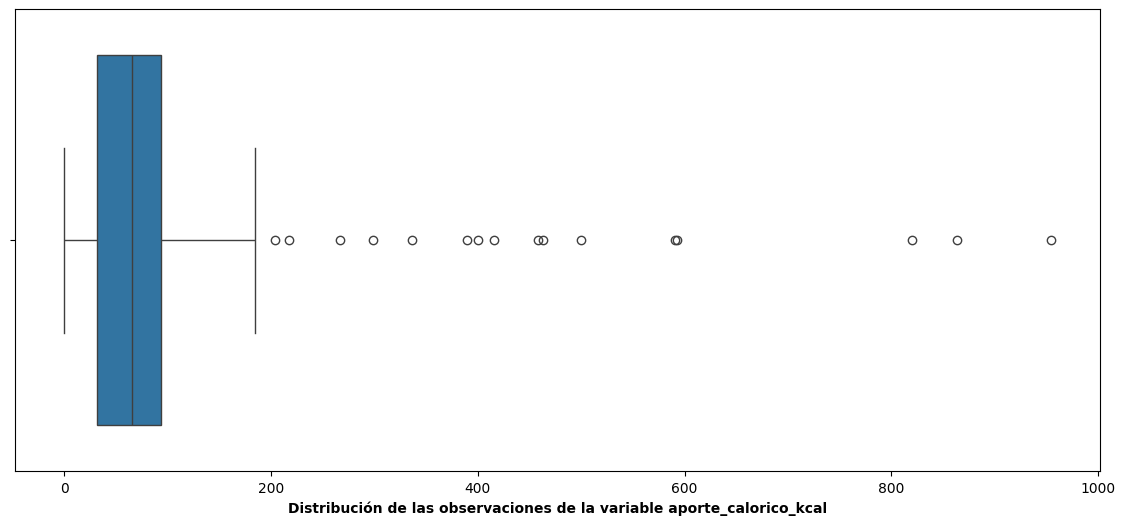

In [ ]:
# Identifique en el gráfico la mediana, el primer y el tercer cuartil.

plt.figure(figsize = (14, 6))


sns.boxplot(x = 'aporte_calorico_kcal', data = df_alimentos)
plt.xlabel('Distribución de las observaciones de la variable aporte_calorico_kcal', fontweight = 'bold')
plt.show()

In [ ]:
# ¿Cómo caracterizaría a la distribución en relación a sus características de simetría?

'''
Es una distribución asimétrica hacia la derecha.

'''

'\nEs una distribución asimétrica hacia la derecha.\n\n'

In [ ]:
# En función a lo observado, ¿qué par de medidas de centralidad/posición
# (media aritmética - mediana) y de dispersión (rango intercuartil - rango -
# desviación estándar) le parece más adecuada para describir a este conjunto?
'''
En función de lo observado en el boxplot, la distribución del aporte calórico presenta 
una marcada asimetría positiva y numerosos valores atípicos. Por este motivo, las medidas 
más adecuadas para describir el conjunto son la mediana como medida de centralidad y el 
rango intercuartil como medida de dispersión, ya que ambas son robustas frente a valores 
extremos.
'''



In [ ]:
# ¿Existe alguna observación que pueda ser considerada como atípica? En caso de
# respuesta afirmativa, ¿cuántas observaciones recibirían esta calificación?

'''
Los valores que están a la derecha del valor Q3 + RI (marcados con círculos
en el ploteo de arriba) puden ser considerados como observaciones atípicas.

'''

print('La cantidad de observaciones es:',
        df_alimentos[df_alimentos['aporte_calorico_kcal'] >= q3 + ri].aporte_calorico_kcal.count())

La cantidad de observaciones es: 17


## Item 4

¿Qué tipo de alimento presenta la mayor mediana de aporte calórico?

In [ ]:
df_alimentos.groupby("tipo_de_alimento")["aporte_calorico_kcal"].median().sort_values(ascending=False)

# El alimento con mayor mediana es el tipo de comida elaborada.

tipo_de_alimento
elaborada     217.0
fruto seco    113.0
fruta          55.0
animal         49.5
verdura        37.0
Name: aporte_calorico_kcal, dtype: float64

## Item 5

Realice un boxplot para representar la distribución de los aportes calóricos de alimentos de los siguientes tipos: frutas, verduras y alimentos elaborados.

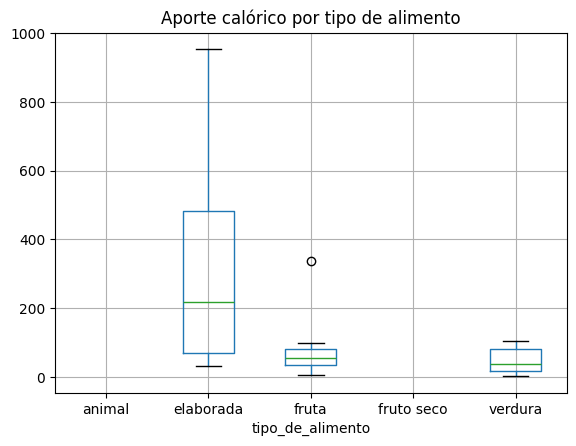

In [ ]:
subset = df_alimentos[df_alimentos["tipo_de_alimento"].isin(["fruta", "verdura", "elaborada"])]


subset.boxplot(column="aporte_calorico_kcal", by="tipo_de_alimento")
plt.title("Aporte calórico por tipo de alimento")
plt.suptitle("")
plt.show()

In [ ]:
# ¿Qué tipo de alimentos presenta valores calóricos más variables y cuál menos variables?

''' 
Las frutas y las verduras presentan una caja menos alta (ri chico) por lo cual sus aporten 
calóricos son menos variables. Por el contrario, la comida elaborada presenta una caja
con mayor altura por lo cual tiene un aporte calorico más variable.
'''

' \nLas frutas y las verduras presentan una caja más baja (IQR chico) por lo cual sus aporten \ncalóricos son menos variables. Por el contrario, la comida elaborada presenta una caja\ncon mayor altura por lo cual tiene un aporte calorico más variable.\n'

In [ ]:
# ¿Qué medida descriptiva utilizó para responder a estas últimas preguntas?

''' 
Para realizar esta comparación se utilizó el rango intercuartil (ri), dado que es una 
medida robusta que describe la dispersión del 50% central de los datos.
'''

## Item 6

Utilizando los datos de los/las pacientes, genere una variable que corresponda a la variación de peso para cada paciente a lo largo del tratamiento (`peso_final_kg` - `peso_inicial_kg`).

In [ ]:
# Represente los valores observados de la variable “diferencia de peso” en función del sexo a través de un boxplot.

# Vamos a crear una variable que represente la diferencia de peso. El signo de esta variable nos dice si el
# paciente bajo se peso si es negativo, y si subió de peso si es positiva. 

df_pacientes["diferencia_peso"] = (df_pacientes["peso_final_kg"] - df_pacientes["peso_inicial_kg"])
df_pacientes.head()

,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias,diferencia_peso
0,398911,78,72,1.80,F,583,-6
1,398912,68,68,1.75,F,159,0
2,398913,92,70,1.85,F,70,-22
3,398914,66,64,1.65,M,41,-2
4,398915,51,50,1.55,F,30,-1


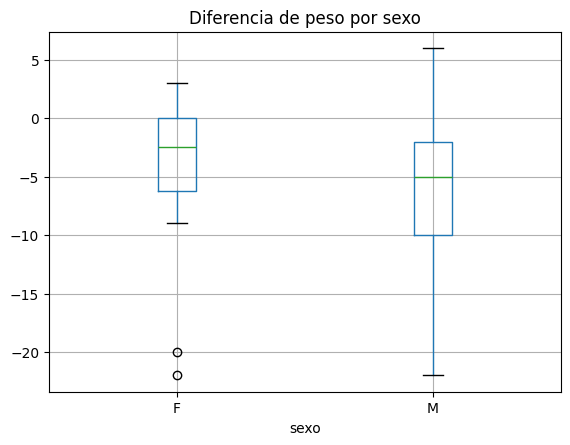

In [ ]:
df_pacientes.boxplot(column="diferencia_peso", by="sexo")
plt.title("Diferencia de peso por sexo")
plt.suptitle("")
plt.show()

In [ ]:
# ¿Qué medida descriptiva utilizaría para comparar los resultados del tratamiento 
# entre personas de ambos sexos? En función de su respuesta, ¿las personas de qué 
# sexo obtuvieron los mejores resultados para el tratamiento?

''' 
Para comparar los resultados del tratamiento entre personas de distintos sexos 
se utilizó la mediana de la variable diferencia de peso, dado que es una medida 
robusta frente a valores atípicos.

A partir del boxplot, se observa que el grupo masculino presenta una mediana más 
baja (más negativa) que el grupo femenino, lo que indica una mayor pérdida de peso. 
Por lo tanto, se concluye que los hombres obtuvieron mejores resultados en el 
tratamiento.
'''


' \nPara comparar los resultados del tratamiento entre personas de distintos sexos \nse utilizó la mediana de la variable diferencia de peso, dado que es una medida \nrobusta frente a valores atípicos.\n\nA partir del boxplot, se observa que el grupo masculino presenta una mediana más \nbaja (más negativa) que el grupo femenino, lo que indica una mayor pérdida de peso. \nPor lo tanto, se concluye que los hombres obtuvieron mejores resultados en el \ntratamiento.\n'